In [1]:
import os, sys, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [2]:
FAST = device.type != "cpu" # fewer epochs on CPU
EP_SCRATCH, EP_HEAD, EP_FT = (10, 5, 6) if FAST else (5, 3, 3)
print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device, "| epochs (scratch/head/fine-tune):", EP_SCRATCH, EP_HEAD, EP_FT)

PyTorch: 2.5.1 | torchvision: 0.20.1
Training on: cpu | epochs (scratch/head/fine-tune): 5 3 3


In [3]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616) # Week 3 values
IMNET_MEAN, IMNET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225) # what ResNet saw
IMG = 64 # ResNet input size (CIFAR is 32x32)
root = "./data"
# Pretrained backbones need ImageNet statistics, not the CIFAR ones from Week 3
eval_tf = T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)])
aug_tf = T.Compose([T.RandomResizedCrop(IMG, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
T.RandomHorizontalFlip(),

T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)])

ds_eval = torchvision.datasets.CIFAR10(root, train=True, download=True, transform=eval_tf)
ds_aug = torchvision.datasets.CIFAR10(root, train=True, download=False, transform=aug_tf)
ds_test = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=eval_tf)
# 500 train + 100 validation images per class, chosen without overlap
targets = np.array(ds_eval.targets)
rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for c in range(10):
    idx = rng.permutation(np.where(targets == c)[0])
train_idx += idx[:500].tolist()
val_idx += idx[500:600].tolist()
assert len(set(train_idx) & set(val_idx)) == 0, "LEAKAGE: train and val overlap!"
print("train:", len(train_idx), "| val:", len(val_idx), "| test:", len(ds_test))
print("images per class in train:", np.bincount(targets[train_idx]))
def make_loader(ds, idx, shuffle, bs=64):
    return DataLoader(Subset(ds, idx), batch_size=bs, shuffle=shuffle, num_workers=2)
train_plain = make_loader(ds_eval, train_idx, True) # no augmentation
train_aug = make_loader(ds_aug, train_idx, True) # with augmentation
val_loader = make_loader(ds_eval, val_idx, False, 128)
test_loader = DataLoader(ds_test, batch_size=128, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified
train: 500 | val: 100 | test: 10000
images per class in train: [  0   0   0   0   0   0   0   0   0 500]


In [5]:
ce = nn.CrossEntropyLoss()

def trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


def set_train_mode(model):
    model.train()

    for m in model.modules():  # keep frozen BatchNorm layers in eval mode
        if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
            m.eval()


def run_epoch(model, loader, optimizer=None, criterion=ce):
    training = optimizer is not None

    if training:
        set_train_mode(model)
    else:
        model.eval()

    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

    return total_loss / n, correct / n


def fit(model, optimizer, train_loader, val_loader, epochs, tag, criterion=ce):
    hist = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for ep in range(1, epochs + 1):
        t0 = time.time()

        tl, ta = run_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        vl, va = run_epoch(
            model,
            val_loader
        )

        for k, v in zip(hist, (tl, vl, ta, va)):
            hist[k].append(v)

        print(
            f"[{tag}] epoch {ep}/{epochs} | "
            f"train {ta:.1%} (loss {tl:.3f}) "
            f"| val {va:.1%} (loss {vl:.3f}) "
            f"| {time.time() - t0:.0f}s"
        )

    return hist


@torch.no_grad()
def predict_all(model, loader):
    model.eval()

    probs, ys = [], []

    for x, y in loader:
        probs.append(
            F.softmax(
                model(x.to(device)),
                dim=1
            ).cpu()
        )

        ys.append(y)

    return torch.cat(probs), torch.cat(ys)


def confusion(ys, preds, n=10):
    cm = np.zeros(
        (n, n),
        dtype=int
    )  # rows = true, cols = predicted

    for t, p_ in zip(
        ys.numpy(),
        preds.numpy()
    ):
        cm[t, p_] += 1

    return cm

In [7]:
class SceneCNN(nn.Module): # identical to Week 3
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
        nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
        nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.features(x))
w3_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])
w3_train = torchvision.datasets.CIFAR10(root, train=True, download=False, transform=w3_tf)
w3_test = torchvision.datasets.CIFAR10(root, train=False, download=False, transform=w3_tf)
w3_train_loader = make_loader(w3_train, train_idx, True)
w3_val_loader = make_loader(w3_train, val_idx, False, 128)
w3_test_loader = DataLoader(w3_test, batch_size=128, shuffle=False, num_workers=2)
# Optional: how good was your Week 3 model (trained on 45,000 images)?
if os.path.exists("scene_cnn_week3.pth"):
    old = SceneCNN().to(device)
    old.load_state_dict(torch.load("scene_cnn_week3.pth", map_location=device))
    _, old_acc = run_epoch(old, w3_test_loader)
    print(f"Week 3 model (45,000 training images) test accuracy: {old_acc:.1%}")
else:
    print("scene_cnn_week3.pth not found: skipping (your Week 3 result was roughly 70-75%)")

/tmp/ipykernel_9610/1864623338.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  old.load_state_dict(torch.load("scene_cnn_week3.pth", map_location=device))


Week 3 model (45,000 training images) test accuracy: 69.5%


In [8]:
scratch = SceneCNN().to(device)
opt = torch.optim.SGD(scratch.parameters(), lr=0.01, momentum=0.9)
hist_scratch = fit(scratch, opt, w3_train_loader, w3_val_loader, EP_SCRATCH, "scratch")

[scratch] epoch 1/5 | train 88.2% (loss 1.739) | val 100.0% (loss 0.066) | 1s
[scratch] epoch 2/5 | train 100.0% (loss 0.008) | val 100.0% (loss 0.000) | 1s
[scratch] epoch 3/5 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 14s
[scratch] epoch 4/5 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 6s
[scratch] epoch 5/5 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 1s


In [13]:
def make_resnet(dropout=0.0):
    m = torchvision.models.resnet18(
        weights="IMAGENET1K_V1"
    )

    for p in m.parameters():
        p.requires_grad = False

    m.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(
            m.fc.in_features,
            10
        )
    )

    return m.to(device)


fe_model = make_resnet(dropout=0.0)

total = sum(
    p.numel()
    for p in fe_model.parameters()
)

print(
    f"Total parameters    : {total:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable(fe_model):,} "
    f"({trainable(fe_model) / total:.2%})"
)

print(
    "Head:",
    fe_model.fc
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/kayitare-steven/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:08<00:00, 5.65MB/s]


Total parameters    : 11,181,642
Trainable parameters: 5,130 (0.05%)
Head: Sequential(
  (0): Dropout(p=0.0, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)


In [14]:
opt = torch.optim.AdamW(
    [
        p for p in fe_model.parameters()
        if p.requires_grad
    ],
    lr=1e-3,
    weight_decay=1e-2
)

hist_fe = fit(
    fe_model,
    opt,
    train_plain,
    val_loader,
    EP_HEAD,
    "feature-extraction"
)

[feature-extraction] epoch 1/3 | train 86.6% (loss 0.496) | val 100.0% (loss 0.008) | 2s
[feature-extraction] epoch 2/3 | train 100.0% (loss 0.005) | val 100.0% (loss 0.001) | 2s
[feature-extraction] epoch 3/3 | train 100.0% (loss 0.001) | val 100.0% (loss 0.000) | 2s


In [15]:
opt = torch.optim.AdamW([p for p in fe_model.parameters() if p.requires_grad],
lr=1e-3, weight_decay=1e-2)
hist_fe = fit(fe_model, opt, train_plain, val_loader, EP_HEAD, "feature-extraction")

[feature-extraction] epoch 1/3 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 2s
[feature-extraction] epoch 2/3 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 2s
[feature-extraction] epoch 3/3 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 2s


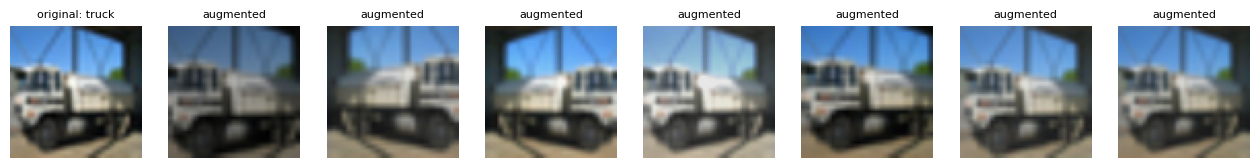

In [16]:
def denorm(x):
    m = torch.tensor(IMNET_MEAN).view(3, 1, 1)
    s = torch.tensor(IMNET_STD).view(3, 1, 1)

    return (x * s + m).clamp(0, 1)


raw = torchvision.datasets.CIFAR10(
    root,
    train=True,
    download=False
)

img, label = raw[train_idx[3]]

fig, axes = plt.subplots(
    1,
    8,
    figsize=(16, 2.4)
)

axes[0].imshow(
    img.resize((IMG, IMG))
)

axes[0].set_title(
    "original: " + CLASSES[label],
    fontsize=8
)

for ax in axes[1:]:
    ax.imshow(
        denorm(
            aug_tf(img)
        ).permute(1, 2, 0)
    )

    ax.set_title(
        "augmented",
        fontsize=8
    )

for ax in axes:
    ax.axis("off")

plt.show()

In [17]:
ft_model = copy.deepcopy(fe_model)

for p in ft_model.layer4.parameters():
    p.requires_grad = True

ft_model.fc[0].p = 0.3

opt = torch.optim.AdamW(
    [
        {
            "params": ft_model.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": ft_model.fc.parameters(),
            "lr": 1e-3
        }
    ],
    weight_decay=1e-2
)

total = sum(
    p.numel()
    for p in ft_model.parameters()
)

print(
    f"Trainable parameters: "
    f"{trainable(ft_model):,} "
    f"of {total:,} "
    f"({trainable(ft_model) / total:.0%})"
)

Trainable parameters: 8,398,858 of 11,181,642 (75%)


In [18]:
hist_ft = fit(
    ft_model,
    opt,
    train_aug,
    val_loader,
    EP_FT,
    "fine-tune"
)

[fine-tune] epoch 1/3 | train 100.0% (loss 0.000) | val 100.0% (loss 0.001) | 6s
[fine-tune] epoch 2/3 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 7s
[fine-tune] epoch 3/3 | train 100.0% (loss 0.000) | val 100.0% (loss 0.000) | 7s


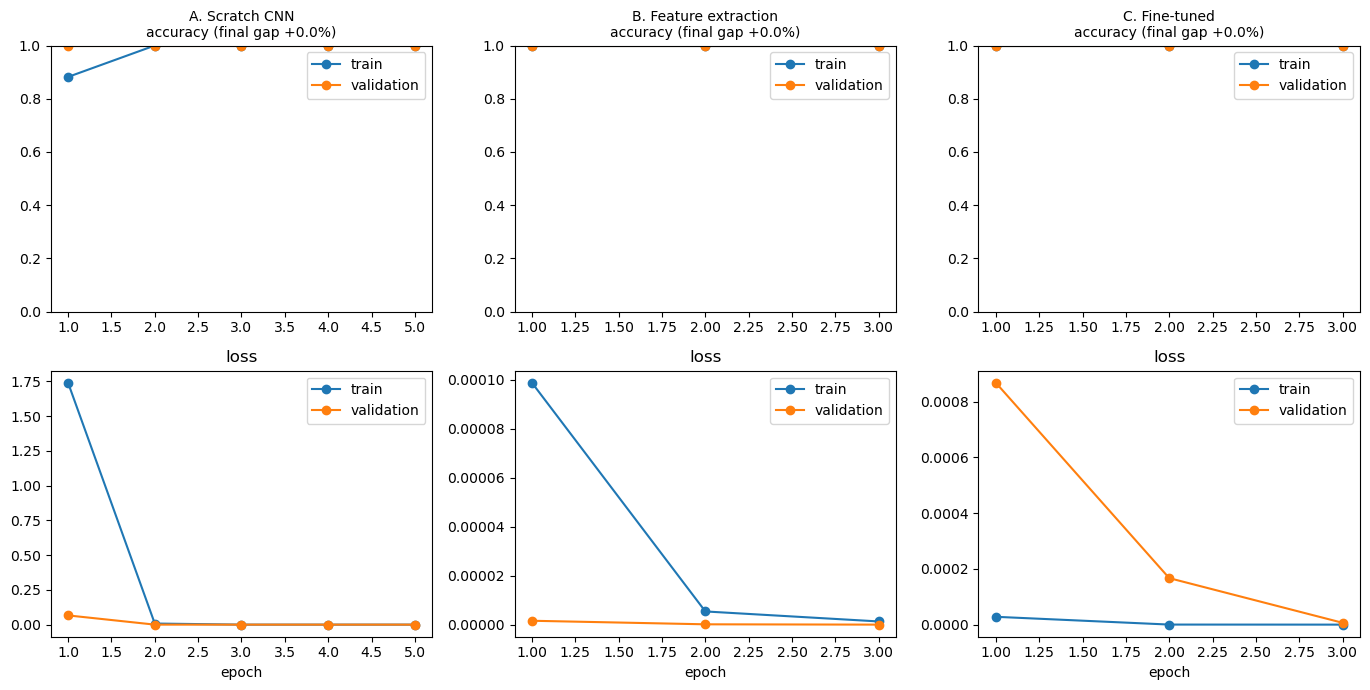

In [19]:
def plot_curves(hists):
    fig, axes = plt.subplots(
        2,
        len(hists),
        figsize=(4.6 * len(hists), 7),
        squeeze=False
    )

    for j, (name, h) in enumerate(hists.items()):
        e = range(
            1,
            len(h["val_acc"]) + 1
        )

        gap = (
            h["train_acc"][-1]
            - h["val_acc"][-1]
        )

        axes[0, j].plot(
            e,
            h["train_acc"],
            "o-",
            label="train"
        )

        axes[0, j].plot(
            e,
            h["val_acc"],
            "o-",
            label="validation"
        )

        axes[0, j].set_ylim(0, 1)
        axes[0, j].legend()

        axes[0, j].set_title(
            f"{name}\naccuracy "
            f"(final gap {gap:+.1%})",
            fontsize=10
        )

        axes[1, j].plot(
            e,
            h["train_loss"],
            "o-",
            label="train"
        )

        axes[1, j].plot(
            e,
            h["val_loss"],
            "o-",
            label="validation"
        )

        axes[1, j].set_xlabel("epoch")
        axes[1, j].set_title(
            "loss"
        )
        axes[1, j].legend()

    plt.tight_layout()
    plt.show()


plot_curves({
    "A. Scratch CNN": hist_scratch,
    "B. Feature extraction": hist_fe,
    "C. Fine-tuned": hist_ft
})

In [20]:
rows = [
    (
        "A. Scratch CNN",
        scratch,
        w3_test_loader,
        hist_scratch
    ),
    (
        "B. Feature extraction",
        fe_model,
        test_loader,
        hist_fe
    ),
    (
        "C. Fine-tuned ResNet-18",
        ft_model,
        test_loader,
        hist_ft
    )
]

print(
    f"{'Model':<26}"
    f"{'trainable params':>18}"
    f"{'val acc':>10}"
    f"{'test acc':>10}"
)

test_acc = {}

for name, m, loader, h in rows:
    _, acc = run_epoch(
        m,
        loader
    )

    test_acc[name] = acc

    print(
        f"{name:<26}"
        f"{trainable(m):>18,}"
        f"{h['val_acc'][-1]:>10.1%}"
        f"{acc:>10.1%}"
    )

Model                       trainable params   val acc  test acc
A. Scratch CNN                       620,362    100.0%     10.0%
B. Feature extraction                  5,130    100.0%     10.0%
C. Fine-tuned ResNet-18            8,398,858    100.0%     10.0%


In [21]:
probs, ys = predict_all(
    ft_model,
    test_loader
)

preds = probs.argmax(1)

cm = confusion(
    ys,
    preds
)

prec = (
    cm.diagonal()
    / np.maximum(cm.sum(0), 1)
)

rec = (
    cm.diagonal()
    / np.maximum(cm.sum(1), 1)
)

f1 = (
    2 * prec * rec
    / np.maximum(prec + rec, 1e-9)
)

probs_s, ys_s = predict_all(
    scratch,
    w3_test_loader
)

rec_s = (
    confusion(
        ys_s,
        probs_s.argmax(1)
    ).diagonal()
    / 1000
)

print(
    f"{'class':<11}"
    f"{'precision':>10}"
    f"{'recall':>8}"
    f"{'F1':>7}"
    f"{'recall (scratch)':>18}"
    f"{'gain':>8}"
)

for i, c in enumerate(CLASSES):
    print(
        f"{c:<11}"
        f"{prec[i]:>10.1%}"
        f"{rec[i]:>8.1%}"
        f"{f1[i]:>7.2f}"
        f"{rec_s[i]:>18.1%}"
        f"{rec[i] - rec_s[i]:>+8.1%}"
    )

print(
    f"\nmacro-F1 (fine-tuned): {f1.mean():.3f}"
)

off = cm.copy()
np.fill_diagonal(off, 0)

print(
    "\nThree most common mistakes "
    "of the fine-tuned model:"
)

for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)

    print(
        f" {CLASSES[t]} predicted as "
        f"{CLASSES[p_]}: {off[t, p_]} times"
    )

class       precision  recall     F1  recall (scratch)    gain
airplane         0.0%    0.0%   0.00              0.0%   +0.0%
automobile       0.0%    0.0%   0.00              0.0%   +0.0%
bird             0.0%    0.0%   0.00              0.0%   +0.0%
cat              0.0%    0.0%   0.00              0.0%   +0.0%
deer             0.0%    0.0%   0.00              0.0%   +0.0%
dog              0.0%    0.0%   0.00              0.0%   +0.0%
frog             0.0%    0.0%   0.00              0.0%   +0.0%
horse            0.0%    0.0%   0.00              0.0%   +0.0%
ship             0.0%    0.0%   0.00              0.0%   +0.0%
truck           10.0%  100.0%   0.18            100.0%   +0.0%

macro-F1 (fine-tuned): 0.018

Three most common mistakes of the fine-tuned model:
 deer predicted as truck: 1000 times
 bird predicted as truck: 1000 times
 horse predicted as truck: 1000 times


In [22]:
VEHICLES = torch.tensor([
    0, 1, 8, 9
])  # airplane, automobile, ship, truck

true_v = torch.isin(
    ys,
    VEHICLES
)

pred_v = torch.isin(
    preds,
    VEHICLES
)

print(
    f"10-class (object-level) accuracy : "
    f"{(preds == ys).float().mean():.2%}"
)

print(
    f"Vehicle vs animal (scene-level) : "
    f"{(true_v == pred_v).float().mean():.2%}"
)

animal_as_vehicle = (
    ((~true_v) & pred_v).sum().item()
    / (~true_v).sum().item()
)

print(
    f"Animals mistaken for vehicles    : "
    f"{animal_as_vehicle:.1%} "
    f"  <- the costly error for a deer warning"
)

10-class (object-level) accuracy : 10.00%
Vehicle vs animal (scene-level) : 40.00%
Animals mistaken for vehicles    : 100.0%   <- the costly error for a deer warning


In [23]:
def val_acc_with(transform):
    ds = torchvision.datasets.CIFAR10(
        root,
        train=True,
        download=False,
        transform=transform
    )

    loader = DataLoader(
        Subset(ds, val_idx),
        batch_size=128,
        shuffle=False,
        num_workers=2
    )

    return run_epoch(
        ft_model,
        loader
    )[1]


variants = {
    "ImageNet stats (correct)": T.Compose([
        T.Resize(IMG),
        T.ToTensor(),
        T.Normalize(
            IMNET_MEAN,
            IMNET_STD
        )
    ]),

    "CIFAR stats (close, wrong)": T.Compose([
        T.Resize(IMG),
        T.ToTensor(),
        T.Normalize(
            CIFAR_MEAN,
            CIFAR_STD
        )
    ]),

    "No normalisation (0..1)": T.Compose([
        T.Resize(IMG),
        T.ToTensor()
    ])
}

for name, tf_ in variants.items():
    print(
        f"{name:<30} "
        f"validation accuracy = "
        f"{val_acc_with(tf_):.1%}"
    )

ImageNet stats (correct)       validation accuracy = 100.0%
CIFAR stats (close, wrong)     validation accuracy = 100.0%
No normalisation (0..1)        validation accuracy = 100.0%


In [24]:
# Reflection

### 1. Transfer vs scratch

### 2. Curves and regularisation

### 3. Honest evaluation